In [7]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict

load_dotenv()

True

In [8]:
model = ChatOpenAI()

In [9]:
# create a state
class LLMState(TypedDict):
    question: str
    answer: str    

In [15]:
def generate_response(state: LLMState) -> LLMState:
    question = state['question']

    answer = model.invoke(question)

    state['answer']= answer.content
    
    return state

In [16]:
# create graph
graph = StateGraph(LLMState)

# create nodes
graph.add_node("generate_response", generate_response)

# add edges
graph.add_edge(START, "generate_response")
graph.add_edge("generate_response", END)

# compile graph
workflow = graph.compile()


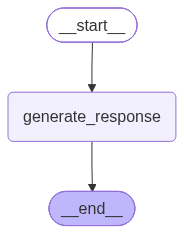

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [18]:
initial_state = {
    "question": "What is the capital of India?"
}

final_state = workflow.invoke(initial_state)

final_state

{'question': 'What is the capital of India?',
 'answer': 'The capital of India is New Delhi.'}